In [30]:
import pandas as pd
import numpy as np


##Exploración inicial de los datasets

In [31]:
#Cargar los datasets
coolers = pd.read_csv('/content/Coolers.csv')
clientes = pd.read_csv('/content/Clientes.csv')
sales_churn_test = pd.read_csv('/content/sales_churn_test.csv')
sales_churn_train = pd.read_csv('/content/sales_churn_train.csv')

In [32]:
coolers.head()

,customer_id,calmonth,num_coolers,num_doors
0,f20e2ea1ca08aceaa24be958f5bfa909c8decda5b6eb8c...,202408,4.0,6
1,a0cbd7668eeae607a12e83411a61b54b57531e14a19d12...,202504,1.0,2
2,ba9cbf8aea2f4619942eb6c0d0e17ebd8bbe31d22b65de...,202504,3.0,5
3,853ab01b0e00dae71612951dc1c4353f4fac482b8de0c7...,202408,1.0,1
4,8c98380fd9d552420b6d7bde9f66d262a020ba83e19b06...,202408,2.0,3


In [33]:
coolers.shape

(4636676, 4)

In [34]:
clientes.head()

,customer_id,territory_d,comercial_subchannel_d,rtm_customer_size_d
0,0c99f37a704e46368b28440a66a44cc988ee3c71b64aa5...,Aguascalientes,Abarrotes y bodegas,Mini
1,a9ea72c0f0a06c6c97714059f339fc65aa6fe8e122a9de...,Aguascalientes,Abarrotes y bodegas,Mediano
2,b1a6b0c122e1e549500512c7d6ae253ea773d59e4a8781...,Aguascalientes,Abarrotes y bodegas,Gigante
3,2964dd973f3387fdf2bd2f07149e900b780639624b5117...,Aguascalientes,Kiosco,Mini
4,9a6f4fb27d8ab6fc5290f0820cfec6c5782d6f7cba167a...,Aguascalientes,Licorería,Mini


In [35]:
clientes.shape

(371727, 4)

In [36]:
sales_churn_train.head()

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target
0,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202410,29,65.166068,0
1,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202411,25,56.640400,0
2,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202412,10,21.486900,0
3,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202501,11,21.698000,0
4,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202502,17,33.709400,0


In [37]:
sales_churn_test.head()

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m
0,78a3c4dcb056e494adb664a80923cd41007807bffac8da...,202602,33,68.226137
1,5621a3ae9697c53b2ecee864d31581db88bbac84bfbd97...,202602,41,56.037887
2,1715d4cc36cbefe1a1a41f40dc8c5bde05c55ce45fc9bc...,202602,36,82.306037
3,ffe8657d7b6790320a28dc0619d11820d108acaa59b179...,202602,49,93.264800
4,09600c13dd26863ba911f9dca4da5b4149cc410930b870...,202602,96,223.377748


##Manipulación del dataset

Creación de variables y fusión en un dataset

In [38]:
import pandas as pd
import numpy as np

#Creación de variables
def construccion_variables(df_ventas, df_coolers, df_clientes, mes_referencia):
    """
    Toma los datasets crudos y los transforma en un renglón por cliente con todas
    las variables calculadas hasta el 'mes_referencia'
    """
    print(f"--- Corte en: {mes_referencia} ---")

    #Filtrar historia hasta el mes de referencia (evita fugas de información)
    v_hist = df_ventas[df_ventas['calmonth'] <= mes_referencia].copy()
    c_hist = df_coolers[df_coolers['calmonth'] <= mes_referencia].copy()

    #Asegurar orden cronológico por cliente
    v_hist = v_hist.sort_values(['customer_id', 'calmonth'])
    c_hist = c_hist.sort_values(['customer_id', 'calmonth'])


    # VARIABLES DE VENTAS (Métricas del Último Mes y Ratios)

    print("\n - Calculando variables del último mes y ratios - ")
    ultimo_mes = v_hist.groupby('customer_id').last().reset_index()

    # Renombrar columnas para identificar que son del último mes activo
    ultimo_mes = ultimo_mes.rename(columns={
        'num_transacciones': 'trans_ult_mes',
        'uni_boxes_sold_m': 'cajas_ult_mes',
        'calmonth': 'ult_mes_activo'
    })

    # Ratio ticket promedio (cajas / transacciones) del último mes
    ultimo_mes['ratio_ticket_prom_ult_mes'] = (
        ultimo_mes['cajas_ult_mes'] / ultimo_mes['trans_ult_mes'].replace(0, np.nan)
    ).fillna(0)

    # Meses desde la última compra (Recencia)
    # Convertimos los meses AAAAMM a enteros para calcular la distancia en meses aproximada
    def diff_meses(m1, m2):
        y1, m1_val = m1 // 100, m1 % 100
        y2, m2_val = m2 // 100, m2 % 100
        return (y1 - y2) * 12 + (m1_val - m2_val)

    ultimo_mes['meses_desde_ult_compra'] = ultimo_mes['ult_mes_activo'].apply(lambda x: diff_meses(mes_referencia, x))


    # PROMEDIOS MÓVILES Y VARIANZAS (3 y 6 Meses)

    print("\n  - Calculando promedios móviles y varianzas (3 y 6 meses) -")

    # Para los últimos 3 meses
    hist_3m = v_hist.groupby('customer_id').tail(3)
    features_3m = hist_3m.groupby('customer_id').agg(
        mean_trans_3m=('num_transacciones', 'mean'),
        mean_cajas_3m=('uni_boxes_sold_m', 'mean'),
        var_trans_3m=('num_transacciones', 'var'),
        var_cajas_3m=('uni_boxes_sold_m', 'var')
    ).reset_index().fillna(0)

    # Para los últimos 6 meses
    hist_6m = v_hist.groupby('customer_id').tail(6)
    features_6m = hist_6m.groupby('customer_id').agg(
        mean_trans_6m=('num_transacciones', 'mean'),
        mean_cajas_6m=('uni_boxes_sold_m', 'mean'),
        var_trans_6m=('num_transacciones', 'var'),
        var_cajas_6m=('uni_boxes_sold_m', 'var')
    ).reset_index().fillna(0)



    # INFRAESTRUCTURA DE COOLERS (Deltas y Ratios)

    print(" \n - Calculando métricas de coolers -")

    # Actualidad de los coolers
    coolers_actual = c_hist.drop_duplicates('customer_id', keep='last').copy()
    coolers_actual = coolers_actual.rename(columns={
        'num_coolers': 'coolers_actual',
        'num_doors': 'doors_actual',
        'calmonth': 'mes_ult_cambio_equipo'
    })

    # Anterioridad de los coolers
    coolers_prev = c_hist.drop_duplicates('customer_id', keep='first').copy()
    coolers_prev = coolers_prev.rename(columns={'num_coolers': 'coolers_prev'})

    # Cambio de equipos (coolers)
    coolers_features = pd.merge(coolers_actual, coolers_prev[['customer_id', 'coolers_prev']], on='customer_id', how='left')
    coolers_features['delta_coolers'] = coolers_features['coolers_actual'] - coolers_features['coolers_prev'].fillna(coolers_features['coolers_actual'])

    # Meses desde el último cambio de equipo conocido
    coolers_features['meses_desde_cambio_equipo'] = coolers_features['mes_ult_cambio_equipo'].apply(lambda x: diff_meses(mes_referencia, x))


    # FUSIÓN INTERNA DE TODAS LAS FEATURES

    print("\n --- Ensamblado del dataset final ---")
    # Unimos bloques de ventas
    master = pd.merge(ultimo_mes, features_3m, on='customer_id', how='left')
    master = pd.merge(master, features_6m, on='customer_id', how='left')

    # Unimos bloques de coolers
    master = pd.merge(master, coolers_features, on='customer_id', how='left')

    # Llenar nulos de clientes que no tienen registros de coolers
    master['coolers_actual'] = master['coolers_actual'].fillna(0)
    master['doors_actual'] = master['doors_actual'].fillna(0)
    master['delta_coolers'] = master['delta_coolers'].fillna(0)
    master['meses_desde_cambio_equipo'] = master['meses_desde_cambio_equipo'].fillna(-1) # -1 significa "nunca ha tenido cambio"

    # Volumen por cooler y tasa coolers/ventas
    master['vol_por_cooler'] = (master['cajas_ult_mes'] / master['coolers_actual'].replace(0, np.nan)).fillna(0)
    master['tasa_coolers_ventas'] = (master['coolers_actual'] / master['mean_cajas_3m'].replace(0, np.nan)).fillna(0)


    # UNIR SEGMENTACIÓN ESTÁTICA (Territorio, subcanal, tamaño)
    master = pd.merge(master, df_clientes, on='customer_id', how='inner')

    # Limpiamos columnas auxiliares que ya no nos sirven para entrenar
    cols_a_eliminar = ['ult_mes_activo', 'mes_ult_cambio_equipo', 'coolers_prev']
    master = master.drop(columns=[c for c in cols_a_eliminar if c in master.columns])

    print(f"\n Dataset generado exitosamente: {master.shape}")
    return master

Aplicación de 'construccion_variables' en train dataset

In [29]:
# Encontrar el mes target
mes_target = sales_churn_train['calmonth'].max()
print(f"El mes a predecir (Target) es: {mes_target}")

# Rescatar la etiqueta 'target' SOLO de ese último mes
df_targets = sales_churn_train[sales_churn_train['calmonth'] == mes_target][['customer_id', 'target']].drop_duplicates()

# Quitamos la columna 'target' de los otros meses para evita colisiones y trampa
ventas_historicas = sales_churn_train[sales_churn_train['calmonth'] < mes_target].drop(columns=['target']).copy()
coolers_historicos = coolers[coolers['calmonth'] < mes_target].copy()

# Encontramos el mes anterior real
mes_previo = ventas_historicas['calmonth'].max()
print(f"Construyendo variables con historia hasta: {mes_previo}")

# Aplicamos el constructor con las nuevas variables
train_variables_features = construccion_variables(
    df_ventas=ventas_historicas,
    df_coolers=coolers_historicos,
    df_clientes=clientes,
    mes_referencia=mes_previo
)

# Unimos las variables limpias con el target real
train_final = pd.merge(train_variables_features, df_targets, on='customer_id', how='inner')

print(f"Dataset generado de forma correcta y listo para utilizar: {train_final.shape}")

El mes a predecir (Target) es: 202601
Construyendo variables con historia hasta: 202512
--- Corte en: 202512 ---

 - Calculando variables del último mes y ratios - 

  - Calculando promedios móviles y varianzas (3 y 6 meses) -
 
 - Calculando métricas de coolers -

 --- Ensamblado del dataset final ---

 Dataset generado exitosamente: (240417, 22)
Dataset generado de forma correcta y listo para utilizar: (198843, 23)


##Cross-Validation

In [39]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score

print(" --- CROSS-VALIDATION --- ")

#  Definimos variables
X = train_final.drop(columns=['customer_id', 'target'])
y = train_final['target']

# Cambio de textos a categorías
columnas_texto = X.select_dtypes(include=['object']).columns
for col in columnas_texto:
    X[col] = X[col].astype('category')

# Definimos el modelo
modelo_cv = lgb.LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    scale_pos_weight = 5
)

# K-Fold (con n=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_auc = cross_val_score(estimator=modelo_cv, X=X, y=y, cv=skf, scoring='roc_auc')

# Resultados
print("\nResultados de cada Fold:")
for i, score in enumerate(resultados_auc, 1):
    print(f"  Fold {i}: AUC = {score:.4f}")

print("\nRESULTADO BASELINE:")
print(f"  AUC Promedio: {np.mean(resultados_auc):.4f}")
print(f"  Desviación estandar: +/- {np.std(resultados_auc):.4f}")

 --- CROSS-VALIDATION --- 

Resultados de cada Fold:
  Fold 1: AUC = 0.9471
  Fold 2: AUC = 0.9588
  Fold 3: AUC = 0.9525
  Fold 4: AUC = 0.9490
  Fold 5: AUC = 0.9406

RESULTADO BASELINE:
  AUC Promedio: 0.9496
  Desviación estandar: +/- 0.0060


Métricas del cross validation

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Obtenemos predicciones (0 a 1) utilizando los valores de K-folds
predicciones_cv = cross_val_predict(estimator=modelo_cv, X=X, y=y, cv=skf)

# Matriz de confusión
matriz = confusion_matrix(y, predicciones_cv)
matriz_df = pd.DataFrame(
    matriz,
    columns=['Predijo: Se Queda (0)', 'Predijo: Se Va (1)'],
    index=['Realmente: Se Queda (0)', 'Realmente: Se Va (1)']
)

print("\n --- MATRIZ DE CONFUSIÓN: ---")
print(matriz_df)
print("\n")
print("-" * 60)

# Reporte de clasificación
print("\n --- REPORTE DE CLASIFICACIÓN: ---")
print(classification_report(y, predicciones_cv, digits=4))


 --- MATRIZ DE CONFUSIÓN: ---
                         Predijo: Se Queda (0)  Predijo: Se Va (1)
Realmente: Se Queda (0)                 195458                1557
Realmente: Se Va (1)                       902                 926


------------------------------------------------------------

 --- REPORTE DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0     0.9954    0.9921    0.9937    197015
           1     0.3729    0.5066    0.4296      1828

    accuracy                         0.9876    198843
   macro avg     0.6842    0.7493    0.7117    198843
weighted avg     0.9897    0.9876    0.9886    198843



##Entrenamiento del modelo

In [41]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("--- Entrenando Modelo Base (Train/Test Split) ---")

# Separación de variables (X) y valor target (Y)
X = train_final.drop(columns=['customer_id', 'target'])
y = train_final['target']

# Convertirsión de texto a tipo category
cat_cols = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']
for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')

# División train-test split (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Configuración el modelo LightGBM
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    scale_pos_weight=5
    #class_weight='balanced'
)

# Entrenamiento del modelo
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

# Obtener predicciones para evaluar
val_probs = model.predict_proba(X_val)[:, 1] # Probabilidad (0.0 a 1.0) para calcular AUC
val_preds = model.predict(X_val)       # Decisión final (0 o 1) para matriz de confusión

# Métricas de evaluación
print("\n" + "="*50)
print(f"ROC AUC: {roc_auc_score(y_val, val_probs):.4f}")
print("="*50)

print("\n --- MATRIZ DE CONFUSIÓN (En el 20% de validación): ---")
matriz = confusion_matrix(y_val, val_preds)
matriz_df = pd.DataFrame(
    matriz,
    columns=['Predijo: Se Queda (0)', 'Predijo: Se Va (1)'],
    index=['Realmente: Se Queda (0)', 'Realmente: Se Va (1)']
)
print(matriz_df)
print("-" * 50)

print("\n --- REPORTE DE CLASIFICACIÓN: ---")
print(classification_report(y_val, val_preds, digits=4))

--- Entrenando Modelo Base (Train/Test Split) ---

ROC AUC: 0.9673

 --- MATRIZ DE CONFUSIÓN (En el 20% de validación): ---
                         Predijo: Se Queda (0)  Predijo: Se Va (1)
Realmente: Se Queda (0)                  39117                 286
Realmente: Se Va (1)                       160                 206
--------------------------------------------------

 --- REPORTE DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0     0.9959    0.9927    0.9943     39403
           1     0.4187    0.5628    0.4802       366

    accuracy                         0.9888     39769
   macro avg     0.7073    0.7778    0.7373     39769
weighted avg     0.9906    0.9888    0.9896     39769



##Interpretacion de resultados

Variables más importantes

In [42]:
# Importancia global de las variables
import pandas as pd

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importances.head(10))

                     Variable  Importancia
18                territory_d          356
1               cajas_ult_mes          202
0               trans_ult_mes          189
6                var_trans_3m          149
16             vol_por_cooler          145
7                var_cajas_3m          143
10               var_trans_6m          139
11               var_cajas_6m          130
2   ratio_ticket_prom_ult_mes          129
19     comercial_subchannel_d          110


Interpretación con Shap

--- Generando Explicaciones SHAP ---


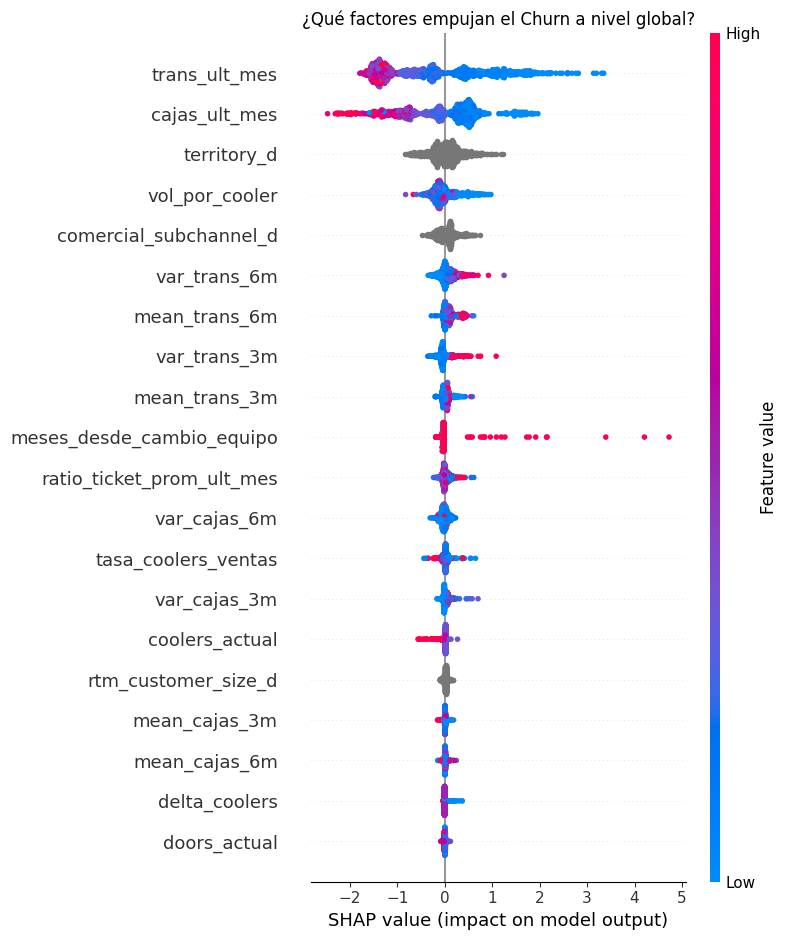

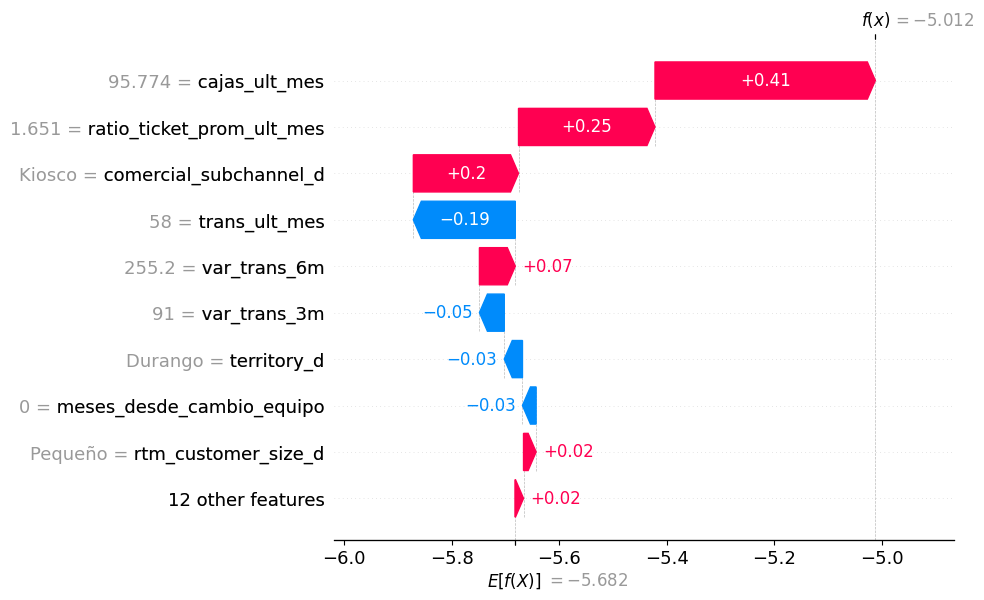

In [43]:
!pip install shap

import shap
import matplotlib.pyplot as plt

print("--- Generando Explicaciones SHAP ---")

# Inicialización del Explainer de Shap
explainer = shap.TreeExplainer(model)

# Se evalua una muestra
X_muestra = X_val.iloc[:1000]

# Se calcula los valores SHAP  para cada cliente
shap_values = explainer(X_muestra)


# Panorama Global - muestra como cada variable afecta en general
plt.figure()
plt.title("¿Qué factores empujan el Churn a nivel global?")
shap.summary_plot(shap_values, X_muestra)


# Plan de acción individual - muestra como cada variable afecta a un cliente en particular
# Buscamos a un cliente que el modelo dijo que se iba con alta probabilidad
idx_cliente_riesgo = 0 # Se toma cualquier número para ver distintos clientes


plt.figure()
shap.plots.waterfall(shap_values[idx_cliente_riesgo])

--- Riesgo por Subcanal Comercial ---


/tmp/ipykernel_2440/1029033407.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis_canal, x='Riesgo_SHAP', y='Subcanal', palette='viridis')


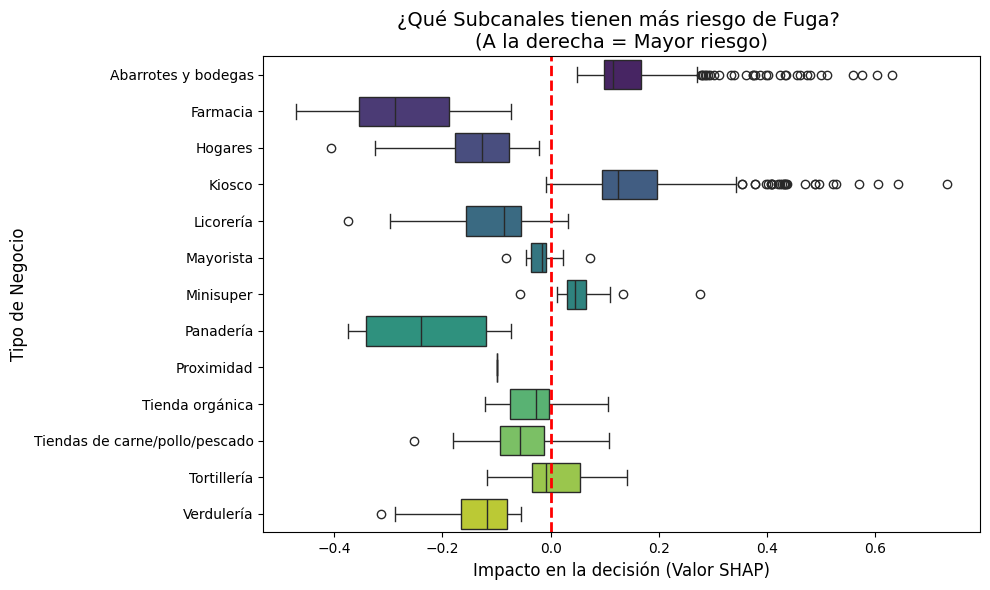

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("--- Riesgo por Subcanal Comercial ---")

# Definir la columna del subcanal
idx_subcanal = X_muestra.columns.get_loc('comercial_subchannel_d')

# Canal con el tipo de subcanal y valores Shap
df_analisis_canal = pd.DataFrame({
    'Subcanal': X_muestra['comercial_subchannel_d'],
    'Riesgo_SHAP': shap_values.values[:, idx_subcanal] # Extraemos los valores de esa columna
})

# Graficar resultados
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analisis_canal, x='Riesgo_SHAP', y='Subcanal', palette='viridis')
plt.axvline(0, color='red', linestyle='--', linewidth=2) # La línea de la muerte (0)
plt.title('¿Qué Subcanales tienen más riesgo de Fuga? \n(A la derecha = Mayor riesgo)', fontsize=14)
plt.xlabel('Impacto en la decisión (Valor SHAP)', fontsize=12)
plt.ylabel('Tipo de Negocio', fontsize=12)
plt.tight_layout()
plt.show()

--- Riesgo por Territorio ---


/tmp/ipykernel_2440/657674668.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis_canal, x='Riesgo_SHAP', y='Territorio', palette='viridis')


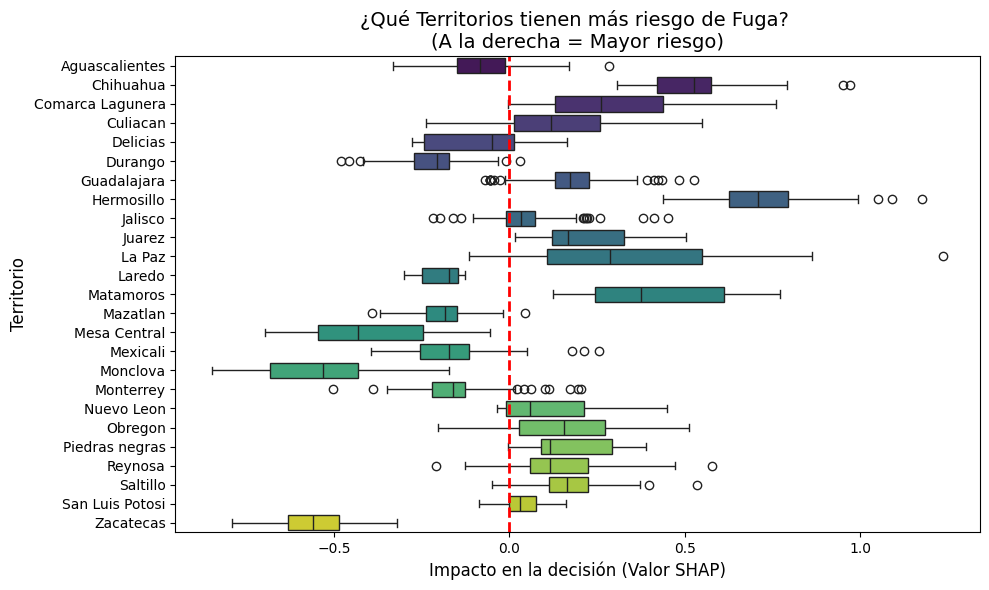

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("--- Riesgo por Territorio ---")

# Definimos la columna de territorio
idx_territory = X_muestra.columns.get_loc('territory_d')

# Canal con el territorio y valores Shap
df_analisis_canal = pd.DataFrame({
    'Territorio': X_muestra['territory_d'],
    'Riesgo_SHAP': shap_values.values[:, idx_territory] # Extraemos los valores de esa columna
})

# Gráfica de resultados
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analisis_canal, x='Riesgo_SHAP', y='Territorio', palette='viridis')
plt.axvline(0, color='red', linestyle='--', linewidth=2) # La línea de la muerte (0)
plt.title('¿Qué Territorios tienen más riesgo de Fuga? \n(A la derecha = Mayor riesgo)', fontsize=14)
plt.xlabel('Impacto en la decisión (Valor SHAP)', fontsize=12)
plt.ylabel('Territorio', fontsize=12)
plt.tight_layout()
plt.show()

 --- Riesgo por Tamaño de Cliente ---


/tmp/ipykernel_2440/2640815450.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analisis_size, x='Riesgo_SHAP', y='Tamaño_Cliente', palette='viridis')


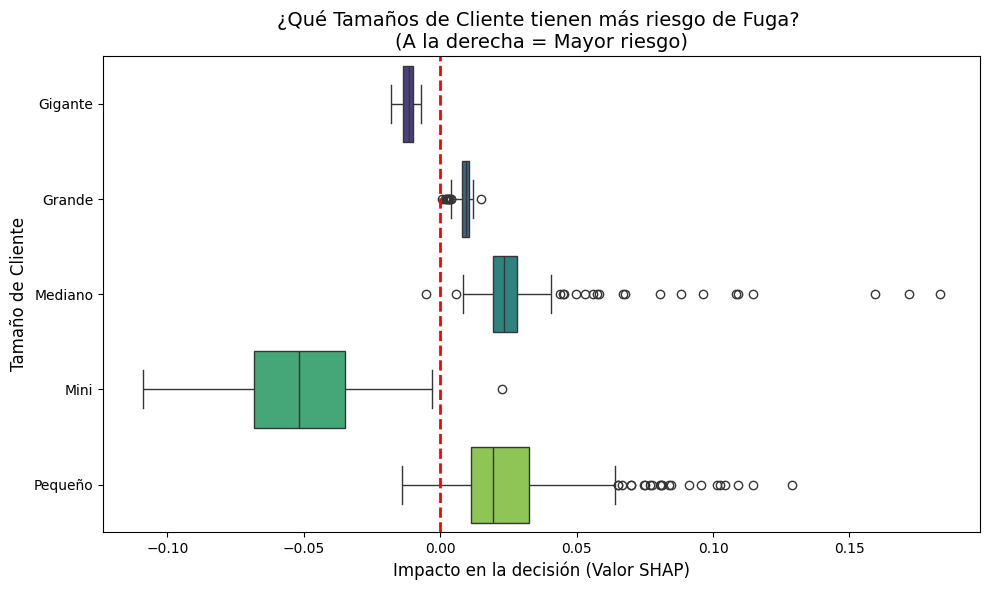

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print(" --- Riesgo por Tamaño de Cliente ---")

# Definimos la columna de tamaño del cliente
idx_size = X_muestra.columns.get_loc('rtm_customer_size_d')

# Canal con el tamaño del cliente y sus valores Shap
df_analisis_size = pd.DataFrame({
    'Tamaño_Cliente': X_muestra['rtm_customer_size_d'],
    'Riesgo_SHAP': shap_values.values[:, idx_size]
})

# Gráfica de resultados
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analisis_size, x='Riesgo_SHAP', y='Tamaño_Cliente', palette='viridis')
plt.axvline(0, color='red', linestyle='--', linewidth=2) # La línea de la muerte (0)
plt.title('¿Qué Tamaños de Cliente tienen más riesgo de Fuga? \n(A la derecha = Mayor riesgo)', fontsize=14)
plt.xlabel('Impacto en la decisión (Valor SHAP)', fontsize=12)
plt.ylabel('Tamaño de Cliente', fontsize=12)
plt.tight_layout()
plt.show()

--- Buscando el Punto de Quiebre (SHAP Scatter Plot) ---


<Figure size 800x600 with 0 Axes>

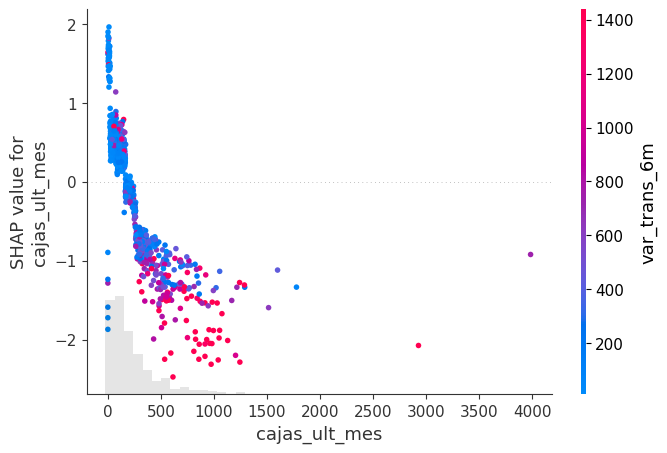

In [47]:
import shap
import matplotlib.pyplot as plt

print("--- Buscando el Punto de Quiebre (SHAP Scatter Plot) ---")

# Elegimos la variable numérica más importante de la gráfica global
variable_clave = "cajas_ult_mes"

# Generamos la gráfica de dependencia para esa variable específica
plt.figure(figsize=(8, 6))
# Usamos el objeto shap_values
shap.plots.scatter(shap_values[:, variable_clave], color=shap_values)


##Predicciones finales y generacion de csv de resultados

Aplicación de 'construcción_variables' en test dataset

In [48]:
# Identificamos el mes de referencia para el test (Normalmente es el último mes)
mes_test = sales_churn_test['calmonth'].max()

# Pasamos el dataset de testing por el constructor de variables para
test_maestro = construccion_variables(
    df_ventas=sales_churn_test,
    df_coolers=coolers,
    df_clientes=clientes,
    mes_referencia=mes_test
)

# Definimos las variables (X_test)
X_test = test_maestro[X.columns] # Usamos X.columns para garantizar el mismo orden

# Convertir las columnas categóricas al tipo 'category'
cat_cols = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']
for col in cat_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

--- Corte en: 202602 ---

 - Calculando variables del último mes y ratios - 

  - Calculando promedios móviles y varianzas (3 y 6 meses) -
 
 - Calculando métricas de coolers -

 --- Ensamblado del dataset final ---

 Dataset generado exitosamente: (199923, 22)


/tmp/ipykernel_2440/1381983987.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].astype('category')
/tmp/ipykernel_2440/1381983987.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].astype('category')
/tmp/ipykernel_2440/1381983987.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [51]:
import pandas as pd
import numpy as np

print("--- Generando predicciones con Niveles de Riesgo ---")

# Obtenemos probabilidades (0.0 a 1.0)
probabilidades = model.predict_proba(X_test)[:, 1]

# Ponemos la columna de probabilidades en el dataset del testing con todas las variables
test_variables['probabilidad_fuga'] = probabilidades

# Clasificamos por riesgo según la probabilidad de desertar
def clasificar_riesgo(prob):
    if prob < 0.35:        # Menos del 35% de probabilidad
        return 'Bajo'
    elif prob < 0.65:      # Entre 35% y 64% de probabilidad
        return 'Medio'
    else:                  # 65% o más
        return 'Alto'

# Agregamos nueva columna con el nivel de risgo según la clasificación
test_variables['nivel_riesgo'] = test_variables['probabilidad_fuga'].apply(clasificar_riesgo)

#Archivo para submission con el clientID y la probabilidad de fuga
entrega_final = pd.DataFrame({
    'customer_id': test_variables['customer_id'],
    'probabilidad_fuga': test_variables['probabilidad_fuga'],
    'nivel_riesgo': test_variables['nivel_riesgo'] #Agregar nivel de riesgo
})

nombre_archivo = 'submission_equipo_final.csv'
entrega_final.to_csv(nombre_archivo, index=False)

#Archivo para análisis y creación de dashboard con toda la información
nombre_archivo_completo = 'testing_completo_con_predicciones.csv'
test_variables.to_csv(nombre_archivo_completo, index=False)

print(f"Ambos archivos fueron generados con éxito")

--- Generando predicciones con Niveles de Riesgo ---
Ambos archivos fueron generados con éxito


In [52]:
import pandas as pd

print("--- Ordenando el archivo final según el Template ---")

# Carga del template dado para la entrega
template = pd.read_csv('/content/preds_submission.csv')

# Merge en el orden de los IDs del template aplicado al csv generado para la entrega
submission_ordenada = template[['customer_id']].merge(
    entrega_final,
    on='customer_id',
    how='left'
)

# Revisar que no falte ningún cliente
nulos = submission_ordenada['probabilidad_fuga'].isnull().sum()
if nulos > 0:
    print(f"ALERTA: Faltan predicciones para {nulos} clientes del template.")
else:
    print("El archivo esta completo, están todos los clientes.")

# Guardar el archivo final
submission_ordenada.to_csv('submission_QueenBits.csv', index=False)

print("El archivo ordenado fue generado con éxito")

--- Ordenando el archivo final según el Template ---
El archivo esta completo, están todos los clientes.
El archivo ordenado fue generado con éxito
